## 4章 多言語の固有認識表現

##### 4.1 データセット
+ XTREME : Cross-lingual TRansfer Evaluation of Multilingal Encoders
+ PAN-Xを探す

In [2]:
from huggingface_hub import notebook_login
# notebook_login()

In [1]:
from pprint import pprint
from datasets import get_dataset_config_names

In [2]:
xtreme_subsets = get_dataset_config_names("xtreme")
pprint(xtreme_subsets)
print(f"XTREME has {len(xtreme_subsets)} configurations")

['MLQA.ar.ar',
 'MLQA.ar.de',
 'MLQA.ar.en',
 'MLQA.ar.es',
 'MLQA.ar.hi',
 'MLQA.ar.vi',
 'MLQA.ar.zh',
 'MLQA.de.ar',
 'MLQA.de.de',
 'MLQA.de.en',
 'MLQA.de.es',
 'MLQA.de.hi',
 'MLQA.de.vi',
 'MLQA.de.zh',
 'MLQA.en.ar',
 'MLQA.en.de',
 'MLQA.en.en',
 'MLQA.en.es',
 'MLQA.en.hi',
 'MLQA.en.vi',
 'MLQA.en.zh',
 'MLQA.es.ar',
 'MLQA.es.de',
 'MLQA.es.en',
 'MLQA.es.es',
 'MLQA.es.hi',
 'MLQA.es.vi',
 'MLQA.es.zh',
 'MLQA.hi.ar',
 'MLQA.hi.de',
 'MLQA.hi.en',
 'MLQA.hi.es',
 'MLQA.hi.hi',
 'MLQA.hi.vi',
 'MLQA.hi.zh',
 'MLQA.vi.ar',
 'MLQA.vi.de',
 'MLQA.vi.en',
 'MLQA.vi.es',
 'MLQA.vi.hi',
 'MLQA.vi.vi',
 'MLQA.vi.zh',
 'MLQA.zh.ar',
 'MLQA.zh.de',
 'MLQA.zh.en',
 'MLQA.zh.es',
 'MLQA.zh.hi',
 'MLQA.zh.vi',
 'MLQA.zh.zh',
 'PAN-X.af',
 'PAN-X.ar',
 'PAN-X.bg',
 'PAN-X.bn',
 'PAN-X.de',
 'PAN-X.el',
 'PAN-X.en',
 'PAN-X.es',
 'PAN-X.et',
 'PAN-X.eu',
 'PAN-X.fa',
 'PAN-X.fi',
 'PAN-X.fr',
 'PAN-X.he',
 'PAN-X.hi',
 'PAN-X.hu',
 'PAN-X.id',
 'PAN-X.it',
 'PAN-X.ja',
 'PAN-X.jv',
 'PAN

In [3]:
panx_subsets = [s for s in xtreme_subsets if s.startswith("PAN")]
panx_subsets[:5]

['PAN-X.af', 'PAN-X.ar', 'PAN-X.bg', 'PAN-X.bn', 'PAN-X.de']

In [4]:
# ドイツ語のコーパスを取得
from datasets import load_dataset

tmp_ds = load_dataset("xtreme", name="PAN-X.de")
print(tmp_ds)
for it in tmp_ds:
    print(it)

DatasetDict({
    train: Dataset({
        features: ['tokens', 'ner_tags', 'langs'],
        num_rows: 20000
    })
    validation: Dataset({
        features: ['tokens', 'ner_tags', 'langs'],
        num_rows: 10000
    })
    test: Dataset({
        features: ['tokens', 'ner_tags', 'langs'],
        num_rows: 10000
    })
})
train
validation
test


In [5]:
# 各言語(ドイツ語, フランス語, イタリア語, 英語)のコーパスから
# 特定の割合でサンプリングしてデータセットを作る
from collections import defaultdict
from datasets import DatasetDict

langs = ["de", "fr", "it", "en"]
fracs = [0.629, 0.229, 0.084, 0.059]

# キーが存在しなければ, DatasetDictを返す
panx_ch = defaultdict(DatasetDict)
for lang, frac in zip(langs, fracs):
    # 単語コーパスをロード
    ds = load_dataset("xtreme", name=f"PAN-X.{lang}")
    # 各分割をシャッフルし、話者の割合に応じてダウンサンプリング
    for split in ds: # train, validation, test
        print(f"langs: {lang}, split: {split}")
        panx_ch[lang][split] = (
            ds[split]
            .shuffle(seed=0)
            .select(range(int(frac * ds[split].num_rows)))
        )



langs: de, split: train
langs: de, split: validation
langs: de, split: test
langs: fr, split: train
langs: fr, split: validation
langs: fr, split: test
langs: it, split: train
langs: it, split: validation
langs: it, split: test
langs: en, split: train
langs: en, split: validation
langs: en, split: test


In [6]:
pprint(panx_ch)

defaultdict(<class 'datasets.dataset_dict.DatasetDict'>,
            {'de': DatasetDict({
    train: Dataset({
        features: ['tokens', 'ner_tags', 'langs'],
        num_rows: 12580
    })
    validation: Dataset({
        features: ['tokens', 'ner_tags', 'langs'],
        num_rows: 6290
    })
    test: Dataset({
        features: ['tokens', 'ner_tags', 'langs'],
        num_rows: 6290
    })
}),
             'en': DatasetDict({
    train: Dataset({
        features: ['tokens', 'ner_tags', 'langs'],
        num_rows: 1180
    })
    validation: Dataset({
        features: ['tokens', 'ner_tags', 'langs'],
        num_rows: 590
    })
    test: Dataset({
        features: ['tokens', 'ner_tags', 'langs'],
        num_rows: 590
    })
}),
             'fr': DatasetDict({
    train: Dataset({
        features: ['tokens', 'ner_tags', 'langs'],
        num_rows: 4580
    })
    validation: Dataset({
        features: ['tokens', 'ner_tags', 'langs'],
        num_rows: 2290
    })
    test

In [7]:
# 各データセットのnum_row属性にアクセスして学習データに含まれる言語ごとの事例を確認
import pandas as pd

pd.DataFrame({lang: [panx_ch[lang]["train"].num_rows] for lang in langs},
             index=["Number of training examples"])

,de,fr,it,en
Number of training examples,12580,4580,1680,1180


In [8]:
pd.DataFrame({lang: [panx_ch[lang]['validation'].num_rows] for lang in langs}, index=["Number of validation examples"])

,de,fr,it,en
Number of validation examples,6290,2290,840,590


In [9]:
pd.DataFrame({lang: [panx_ch[lang]['test'].num_rows] for lang in langs}, index=["Number of test examples"])

,de,fr,it,en
Number of test examples,6290,2290,840,590


In [11]:
# ドイツ語コーパスに含まれる一つの事例を検証
pprint(panx_ch['de'])
print('---')
element = panx_ch['de']['train'][0]
for key, value in element.items():
    print(f"{key}: {value}")

DatasetDict({
    train: Dataset({
        features: ['tokens', 'ner_tags', 'langs'],
        num_rows: 12580
    })
    validation: Dataset({
        features: ['tokens', 'ner_tags', 'langs'],
        num_rows: 6290
    })
    test: Dataset({
        features: ['tokens', 'ner_tags', 'langs'],
        num_rows: 6290
    })
})
---
tokens: ['2.000', 'Einwohnern', 'an', 'der', 'Danziger', 'Bucht', 'in', 'der', 'polnischen', 'Woiwodschaft', 'Pommern', '.']
ner_tags: [0, 0, 0, 0, 5, 6, 0, 0, 5, 5, 6, 0]
langs: ['de', 'de', 'de', 'de', 'de', 'de', 'de', 'de', 'de', 'de', 'de', 'de']


In [12]:
pprint(panx_ch['de']['train'].features)
print('---')
for key, value in panx_ch["de"]["train"].features.items():
    print(f"{key}: {value}")

{'langs': Sequence(feature=Value(dtype='string', id=None), length=-1, id=None),
 'ner_tags': Sequence(feature=ClassLabel(names=['O',
                                                'B-PER',
                                                'I-PER',
                                                'B-ORG',
                                                'I-ORG',
                                                'B-LOC',
                                                'I-LOC'],
                                         id=None),
                      length=-1,
                      id=None),
 'tokens': Sequence(feature=Value(dtype='string', id=None), length=-1, id=None)}
---
tokens: Sequence(feature=Value(dtype='string', id=None), length=-1, id=None)
ner_tags: Sequence(feature=ClassLabel(names=['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC'], id=None), length=-1, id=None)
langs: Sequence(feature=Value(dtype='string', id=None), length=-1, id=None)


In [13]:
panx_ch["de"]["train"]

Dataset({
    features: ['tokens', 'ner_tags', 'langs'],
    num_rows: 12580
})

In [14]:
ner_tags = panx_ch["de"]["train"].features['ner_tags']
ner_tags

Sequence(feature=ClassLabel(names=['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC'], id=None), length=-1, id=None)

In [15]:
ner_tags.feature

ClassLabel(names=['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC'], id=None)

In [16]:
ner_tags.feature.__dict__

{'names': ['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC'],
 'id': None,
 'num_classes': 7,
 'names_file': None,
 '_int2str': ['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC'],
 '_str2int': {'O': 0,
  'B-PER': 1,
  'I-PER': 2,
  'B-ORG': 3,
  'I-ORG': 4,
  'B-LOC': 5,
  'I-LOC': 6}}

In [17]:
tags = panx_ch["de"]["train"].features["ner_tags"].feature
print("tag: ", tags)
print(tags.__dict__)

tag:  ClassLabel(names=['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC'], id=None)
{'names': ['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC'], 'id': None, 'num_classes': 7, 'names_file': None, '_int2str': ['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC'], '_str2int': {'O': 0, 'B-PER': 1, 'I-PER': 2, 'B-ORG': 3, 'I-ORG': 4, 'B-LOC': 5, 'I-LOC': 6}}


In [18]:
def create_tag_names(batch):
    # tagsは int <-> str の変換ルール.
    return {"ner_tags_str": [tags.int2str(idx) for idx in batch["ner_tags"]]}

In [19]:
panx_ch["de"]

DatasetDict({
    train: Dataset({
        features: ['tokens', 'ner_tags', 'langs'],
        num_rows: 12580
    })
    validation: Dataset({
        features: ['tokens', 'ner_tags', 'langs'],
        num_rows: 6290
    })
    test: Dataset({
        features: ['tokens', 'ner_tags', 'langs'],
        num_rows: 6290
    })
})

In [20]:
panx_de = panx_ch["de"].map(create_tag_names)

In [21]:
panx_de

DatasetDict({
    train: Dataset({
        features: ['tokens', 'ner_tags', 'langs', 'ner_tags_str'],
        num_rows: 12580
    })
    validation: Dataset({
        features: ['tokens', 'ner_tags', 'langs', 'ner_tags_str'],
        num_rows: 6290
    })
    test: Dataset({
        features: ['tokens', 'ner_tags', 'langs', 'ner_tags_str'],
        num_rows: 6290
    })
})

In [22]:
de_example = panx_de["train"][0] # trainデータの一つ目
pd.DataFrame([de_example["tokens"], de_example["ner_tags_str"]], ["Tokens", "Tags"])

,0,1,2,3,4,5,6,7,8,9,10,11
Tokens,2.000,Einwohnern,an,der,Danziger,Bucht,in,der,polnischen,Woiwodschaft,Pommern,.
Tags,O,O,O,O,B-LOC,I-LOC,O,O,B-LOC,B-LOC,I-LOC,O


In [23]:
# タグに異常な不均衡がないことを簡単に確認するために
# 各分割における各固有表現の頻度を計算する
from collections import Counter

split2freqs = defaultdict(Counter)
for split, dataset in panx_de.items():
    for row in dataset["ner_tags_str"]:
        for tag in row:
            if tag.startswith("B"):
                tag_type = tag.split("-")[1]
                split2freqs[split][tag_type] += 1

pd.DataFrame.from_dict(split2freqs, orient="index")

,LOC,ORG,PER
train,6186,5366,5810
validation,3172,2683,2893
test,3180,2573,3071


学習用モデルのボディを取得

In [24]:
# BERTとXML-Rをロード
from transformers import AutoTokenizer

bert_model_name = "bert-base-cased"
xlmr_model_name = "xlm-roberta-base"
bert_tokenizer = AutoTokenizer.from_pretrained(bert_model_name)
xlmr_tokenizer = AutoTokenizer.from_pretrained(xlmr_model_name)

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


In [25]:
# テキストをエンコードすることで、各モデルが事前学習時に使用した特殊トークンを取得できる
text = "Jack Sparrow loves New York!"
bert_tokens = bert_tokenizer(text).tokens()
xlmr_tokens = xlmr_tokenizer(text).tokens()
print(bert_tokens) # [CLS], ##, [SEP] ... WordPiece
print(xlmr_tokens) # <s>, _***, </s> ... SentencePiece

['[CLS]', 'Jack', 'Spa', '##rrow', 'loves', 'New', 'York', '!', '[SEP]']
['<s>', '▁Jack', '▁Spar', 'row', '▁love', 's', '▁New', '▁York', '!', '</s>']


In [26]:
# SentencePieceトークナイザー
"".join(xlmr_tokens) # _ : Lower One Quarter Block

'<s>▁Jack▁Sparrow▁loves▁New▁York!</s>'

In [27]:
"".join(xlmr_tokens).replace(u"\u2581", " ")

'<s> Jack Sparrow loves New York!</s>'

In [28]:
import torch.nn as nn
from transformers import XLMRobertaConfig
from transformers.modeling_outputs import TokenClassifierOutput
from transformers.models.roberta.modeling_roberta import RobertaModel
from transformers.models.roberta.modeling_roberta import RobertaPreTrainedModel

class XLMRobertaForTokenClassification(RobertaPreTrainedModel):
    config_class = XLMRobertaConfig

    def __init__(self, config):
        super().__init__(config)
        self.num_labels = config.num_labels
        # モデルボディのロード
        self.roberta = RobertaModel(config, add_pooling_layer=False) # add_pooling_layer=Falseで[CLS]以外の全ての出力に関連する隠れ層の重みを取り出す
        # トークン分類ヘッドの用意
        self.dropout = nn.Dropout(config.hidden_dropout_prob)
        self.classifier = nn.Linear(config.hidden_size, config.num_labels)
        # 重みのロードと初期化
        self.init_weights() # RobertaPreTrainedModel

    def forward(self,
                input_ids=None,
                attention_mask=None,
                token_type_ids=None,
                labels=None,
                **kwargs):
        # モデルボディを使ってエンコーダの表現を取得
        outputs = self.roberta(input_ids, attention_mask=attention_mask,
                               token_type_ids=token_type_ids, **kwargs)

        # 分類器をエンコーダ表現に適用(ヘッド)
        sequence_output = self.dropout(outputs[0])
        logits = self.classifier(sequence_output)

        # 損失の計算(forwardで予測誤差を一応計算)
        loss = None
        if labels is not None:
            # もしアテンションマスクがあれば、マスクしていない部分のみのトークンで損失を計算すべき
            loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(logits.view(-1, self.num_labels), labels.view(-1))

        # モデルの出力オブジェクトを返す
        return TokenClassifierOutput(loss=loss, logits=logits,
                                     hidden_states=outputs.hidden_states,
                                     attentions=outputs.attentions)




In [29]:
index2tag = {idx: tag for idx, tag in enumerate(tags.names)}
tag2index = {tag: idx for idx, tag in enumerate(tags.names)}
print(f"index2tag: {index2tag}")
print(f"tag2index: {tag2index}")

index2tag: {0: 'O', 1: 'B-PER', 2: 'I-PER', 3: 'B-ORG', 4: 'I-ORG', 5: 'B-LOC', 6: 'I-LOC'}
tag2index: {'O': 0, 'B-PER': 1, 'I-PER': 2, 'B-ORG': 3, 'I-ORG': 4, 'B-LOC': 5, 'I-LOC': 6}


In [30]:
from transformers import AutoConfig

xlmr_config = AutoConfig.from_pretrained(xlmr_model_name,
                                         num_labels=tags.num_classes,
                                         index2label=index2tag, label2id=tag2index)
print(xlmr_config)

XLMRobertaConfig {
  "_name_or_path": "xlm-roberta-base",
  "architectures": [
    "XLMRobertaForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": 0,
  "classifier_dropout": null,
  "eos_token_id": 2,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "id2label": {
    "0": "LABEL_0",
    "1": "LABEL_1",
    "2": "LABEL_2",
    "3": "LABEL_3",
    "4": "LABEL_4",
    "5": "LABEL_5",
    "6": "LABEL_6"
  },
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "label2id": {
    "B-LOC": 5,
    "B-ORG": 3,
    "B-PER": 1,
    "I-LOC": 6,
    "I-ORG": 4,
    "I-PER": 2,
    "O": 0
  },
  "layer_norm_eps": 1e-05,
  "max_position_embeddings": 514,
  "model_type": "xlm-roberta",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "output_past": true,
  "pad_token_id": 1,
  "position_embedding_type": "absolute",
  "transformers_version": "4.16.2",
  "type_vocab_size": 1,
  "use_cache": true,
  "vocab_size": 250002
}



In [31]:
import torch

print(torch.cuda.device_count())
print(torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device: %s" % device)
# xlmr_config = xlmr_config.to(device)
xlmr_model = (XLMRobertaForTokenClassification
              .from_pretrained(xlmr_model_name, config=xlmr_config)
              .to(device))


2
True
device: cuda


C:\Users\InoueShinichi\.conda\envs\Book_Transformers\Lib\site-packages\transformers\modeling_utils.py:1435: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.

In [32]:
# トークナイザーとモデルの動作チェック
input_ids = xlmr_tokenizer.encode(text, return_tensors="pt")
pd.DataFrame([xlmr_tokens, input_ids[0].numpy()], index=["Tokens", "Input IDs"])

,0,1,2,3,4,5,6,7,8,9
Tokens,<s>,▁Jack,▁Spar,row,▁love,s,▁New,▁York,!,</s>
Input IDs,0,21763,37456,15555,5161,7,2356,5753,38,2


In [33]:
outputs = xlmr_model(input_ids.to(device)).logits
pprint(outputs)
print(outputs.size())
predictions = torch.argmax(outputs, dim=-1)
pprint(predictions)
print(f"Number of tokens in sequence: {len(xlmr_tokens)}")
print(f"Shape of outputs: {outputs.shape}") # (Batch,Token,Class)

tensor([[[-0.2930, -0.1337, -0.2014, -0.2097,  0.5716,  0.2917, -0.2941],
         [-0.3626, -0.2795, -0.1375, -0.1530,  0.4011,  0.5168, -0.2449],
         [-0.3704, -0.1927, -0.1863, -0.1154,  0.4569,  0.5487, -0.4175],
         [-0.3687, -0.2923, -0.2662, -0.1093,  0.3511,  0.5834, -0.3231],
         [-0.2358, -0.2247, -0.0924, -0.0856,  0.2479,  0.5486, -0.3418],
         [-0.3369, -0.4010, -0.1237, -0.1424,  0.3191,  0.4122, -0.3967],
         [-0.2877, -0.2768, -0.0976, -0.1410,  0.3713,  0.4074, -0.2798],
         [-0.2552, -0.2127, -0.1743, -0.1352,  0.3204,  0.4504, -0.2249],
         [-0.2403, -0.2474, -0.1330, -0.1509,  0.2342,  0.6082, -0.2632],
         [-0.2253, -0.2031, -0.1968, -0.1766,  0.5648,  0.2855, -0.3010]]],
       device='cuda:0', grad_fn=<ViewBackward0>)
torch.Size([1, 10, 7])
tensor([[4, 5, 5, 5, 5, 5, 5, 5, 5, 4]], device='cuda:0')
Number of tokens in sequence: 10
Shape of outputs: torch.Size([1, 10, 7])


ファインチューニングしていないので適当な値が出る

In [34]:
preds = [tags.names[p] for p in predictions[0].cpu().numpy()]
pd.DataFrame([xlmr_tokens, preds], index=["Tokens", "Tags"]) # ファインチューニングしていないので適当な値が出る

,0,1,2,3,4,5,6,7,8,9
Tokens,<s>,▁Jack,▁Spar,row,▁love,s,▁New,▁York,!,</s>
Tags,I-ORG,B-LOC,B-LOC,B-LOC,B-LOC,B-LOC,B-LOC,B-LOC,B-LOC,I-ORG


In [35]:
# ファインチューニングのためのヘルパー関数
def tag_text(text, tags, model, tokenizer):
    # 特殊な文字列を含むトークンを取得
    tokens = tokenizer(text).tokens()
    # 系列をIDにエンコード
    input_ids = xlmr_tokenizer(text, return_tensors="pt").input_ids.to(device) # cpu -> cuda:0
    # 7つのクラス分布にわたる予測を得る
    outputs = model(input_ids)[0] # (B, S, Class) -> (S, Class)
    # argmaxを使い、トークンごとに尤も可能性の高いクラスを取得
    predictions = torch.argmax(outputs, dim=2)
    # DataFrameへ変換
    preds = [tags.names[p] for p in predictions[0].cpu().numpy()]
    return pd.DataFrame([tokens, preds], index=["Tokens", "Tags"])

#### データセット全体をトークン化して, XLM-Rモデルに渡してファインチューニング

In [36]:
# 単語とNERラベル
pprint(de_example)
words, labels = de_example["tokens"], de_example["ner_tags"]
print(words)
print(labels)

{'langs': ['de',
           'de',
           'de',
           'de',
           'de',
           'de',
           'de',
           'de',
           'de',
           'de',
           'de',
           'de'],
 'ner_tags': [0, 0, 0, 0, 5, 6, 0, 0, 5, 5, 6, 0],
 'ner_tags_str': ['O',
                  'O',
                  'O',
                  'O',
                  'B-LOC',
                  'I-LOC',
                  'O',
                  'O',
                  'B-LOC',
                  'B-LOC',
                  'I-LOC',
                  'O'],
 'tokens': ['2.000',
            'Einwohnern',
            'an',
            'der',
            'Danziger',
            'Bucht',
            'in',
            'der',
            'polnischen',
            'Woiwodschaft',
            'Pommern',
            '.']}
['2.000', 'Einwohnern', 'an', 'der', 'Danziger', 'Bucht', 'in', 'der', 'polnischen', 'Woiwodschaft', 'Pommern', '.']
[0, 0, 0, 0, 5, 6, 0, 0, 5, 5, 6, 0]


In [37]:
# 単語をトークン化
tokenized_input = xlmr_tokenizer(de_example["tokens"], is_split_into_words=True)
tokens = xlmr_tokenizer.convert_ids_to_tokens(tokenized_input["input_ids"])
pd.DataFrame([tokens], index=["Tokens"])

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
Tokens,<s>,▁2.000,▁Einwohner,n,▁an,▁der,▁Dan,zi,ger,▁Buch,...,▁Wo,i,wod,schaft,▁Po,mmer,n,▁,.,</s>


In [38]:
# トークンをサブワードに分割した場合のラベル対応は先頭のみとする慣習に従うとする
# e.g. Einwohnern -> _Einwohner と n -> _Einwohnerのみに「B-LOC」ラベルを付与する
# word_ids()でマスキングできる
word_ids = tokenized_input.word_ids()
pd.DataFrame([tokens, word_ids], index=["Tokens", "Word IDs"])

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
Tokens,<s>,▁2.000,▁Einwohner,n,▁an,▁der,▁Dan,zi,ger,▁Buch,...,▁Wo,i,wod,schaft,▁Po,mmer,n,▁,.,</s>
Word IDs,None,0,1,1,2,3,4,4,4,5,...,9,9,9,9,10,10,10,11,11,None


In [39]:
# 学習時に利用しない特殊なトークンや学習時にマスクしたいサブワードのラベルを-100とする
previous_word_idx = None
label_ids = []

for word_idx in word_ids: # word_ids: サブワードの塊
    if word_idx is None or word_idx == previous_word_idx:
        label_ids.append(-100)
    elif word_idx != previous_word_idx:
        label_ids.append(labels[word_idx])
    previous_word_idx = word_idx

labels = [index2tag[l] if l != -100 else "IGN" for l in label_ids]
index = ["Tokens", "Word IDs", "Label IDs", "Labels"]

pd.DataFrame([tokens, word_ids, label_ids, labels], index=index)

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
Tokens,<s>,▁2.000,▁Einwohner,n,▁an,▁der,▁Dan,zi,ger,▁Buch,...,▁Wo,i,wod,schaft,▁Po,mmer,n,▁,.,</s>
Word IDs,None,0,1,1,2,3,4,4,4,5,...,9,9,9,9,10,10,10,11,11,None
Label IDs,-100,0,0,-100,0,0,5,-100,-100,6,...,5,-100,-100,-100,6,-100,-100,0,-100,-100
Labels,IGN,O,O,IGN,O,O,B-LOC,IGN,IGN,I-LOC,...,B-LOC,IGN,IGN,IGN,I-LOC,IGN,IGN,O,IGN,IGN


In [40]:
print(panx_de["train"])
trn_examples = panx_de["train"]
trn_examples
trn_examples['tokens']
tokenized_inputs = xlmr_tokenizer(list(trn_examples['tokens']), truncation=True, is_split_into_words=True)
tokenized_inputs[:2]

Dataset({
    features: ['tokens', 'ner_tags', 'langs', 'ner_tags_str'],
    num_rows: 12580
})


[Encoding(num_tokens=25, attributes=[ids, type_ids, tokens, offsets, attention_mask, special_tokens_mask, overflowing]),
 Encoding(num_tokens=19, attributes=[ids, type_ids, tokens, offsets, attention_mask, special_tokens_mask, overflowing])]

In [41]:
# データセット全体に上記セルを適用する関数
def tokenize_and_align_labels(examples): # examples: 'train', 'validation', 'test'
    tokenized_inputs = xlmr_tokenizer(examples["tokens"], truncation=True, is_split_into_words=True)
    labels = []
    for idx, label in enumerate(examples["ner_tags"]):
        word_ids = tokenized_inputs.word_ids(batch_index=idx)
        previous_word_idx = None
        label_ids = []
        for word_idx in word_ids:
            if word_idx is None or word_idx == previous_word_idx:
                label_ids.append(-100) # torch.nn.CrossEntropyLossにignore_index属性があり、これが-100
            else:
                label_ids.append(label[word_idx])
            previous_word_idx = word_idx
        labels.append(label_ids)
    tokenized_inputs["labels"] = labels
    return tokenized_inputs

In [42]:
# 反復処理用関数
def encode_panx_dataset(corpus): # corpus: DatasetDict
    return corpus.map(tokenize_and_align_labels, batched=True,
                      remove_columns=["langs", "ner_tags", "tokens"])


In [43]:
# DatasetDictに適用して分割ごとにエンコードされたDatasetを得ることができる
panx_de_encoded = encode_panx_dataset(panx_ch["de"])
panx_de_encoded

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 12580
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 6290
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 6290
    })
})

In [44]:
trn_labels_0 = panx_de_encoded["train"]["labels"][0]
trn_input_ids_0 = panx_de_encoded["train"]["input_ids"][0]
trn_attention_mask_0 = panx_de_encoded["train"]["attention_mask"][0]

pd.DataFrame([trn_labels_0, trn_attention_mask_0, trn_input_ids_0], index=["label", "amask", 'input_id'])

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
label,-100,0,0,-100,0,0,5,-100,-100,6,...,5,-100,-100,-100,6,-100,-100,0,-100,-100
amask,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
input_id,0,70101,176581,19,142,122,2290,708,1505,18363,...,13787,14,15263,18917,663,6947,19,6,5,2


In [ ]:
val_labels_0 = panx_de_encoded['validation']['labels'][0]
val_input_ids_0 = panx_de_encoded['validation']['input_ids'][0]
val_attention_mask_0 = panx_de_encoded['validation']['attention_mask'][0]

pd.DataFrame([val_labels_0, val_attention_mask_0, val_input_ids_0], index=["label", "amask", 'input_id'])

#### 性能指標
+ 固有表現認識モデルの評価では、(精度、再現率、F1スコア)を報告する
+ seqevalライブラリを使う

In [45]:
# seqevalライブラリの使用例
from seqeval.metrics import classification_report

# 固有表現認識のタグ
y_true: list[list] = [
    ["0", "0", "0", "B-MISC", "I-MISC", "I-MISC", "0"],
    ["B-PER", "I-PER", "0"]
]

# モデルの予測
y_pred: list[list] = [
    ["0", "0", "B-MISC", "I-MISC", "I-MISC", "I-MISC", "0"],
    ["B-PER", "I-PER", "0"]
]

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

        MISC       0.00      0.00      0.00         1
         PER       1.00      1.00      1.00         1
           _       0.00      0.00      0.00         1

   micro avg       0.33      0.33      0.33         3
   macro avg       0.33      0.33      0.33         3
weighted avg       0.33      0.33      0.33         3



C:\Users\InoueShinichi\.conda\envs\Book_Transformers\Lib\site-packages\seqeval\metrics\sequence_labeling.py:171: UserWarning: 0 seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))


In [46]:
# 学習中にseqevalを適用するための関数
import numpy as np

def align_predictions(predictions, label_ids):
    preds = np.argmax(predictions, axis=2)
    batch_size, seq_len = preds.shape
    labels_list, preds_list = [], []

    for batch_idx in range(batch_size):
        example_labels, example_preds = [], []
        for seq_idx in range(seq_len):
            # ラベルIDが-100の場合は無視
            if label_ids[batch_idx, seq_idx] != -100:
                example_labels.append(index2tag[label_ids[batch_idx][seq_idx]])
                example_preds.append(index2tag[preds[batch_idx][seq_idx]])

            labels_list.append(example_labels)
            preds_list.append(example_preds)

    return preds_list, labels_list


+ PAN-Xのドイツ語サブセットでベースモデルをファインチューニング
+ フランス語、イタリア語、英語でゼロショット言語観転移性能を評価する

In [47]:
from transformers import TrainingArguments

num_epochs = 3
batch_size = 24
logging_steps = len(panx_de_encoded["train"]) // batch_size
model_name = f"{xlmr_model_name}-finetuned-panx-de"
training_args = TrainingArguments(
    output_dir=model_name,
    log_level="error",
    num_train_epochs=num_epochs,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    evaluation_strategy="epoch",
    save_steps=1e6,
    weight_decay=0.01,
    disable_tqdm=False,
    logging_steps=logging_steps,
    push_to_hub=False
)

In [46]:
# Huffing Face Hubにログインしていることを確認
from huggingface_hub import notebook_login
# notebook_login()

In [48]:
# F1スコアの計算
from seqeval.metrics import f1_score

def compute_metrics(eval_pred):
    y_pred, y_true = align_predictions(eval_pred.predictions, eval_pred.label_ids)
    return {"f1": f1_score(y_true, y_pred)}

In [49]:
# データコレータ(data collator)を定義して各入力系列をバッチで最大の系列長になるようにパディングする
from transformers import DataCollatorForTokenClassification

data_collator = DataCollatorForTokenClassification(xlmr_tokenizer)

In [50]:
def model_init():
    return (XLMRobertaForTokenClassification
            .from_pretrained(xlmr_model_name, config=xlmr_config)
            .to(device))

In [51]:
from transformers import Trainer

trainer = Trainer(model_init=model_init,
                  args=training_args,
                  data_collator=data_collator,
                  compute_metrics=compute_metrics,
                  train_dataset=panx_de_encoded["train"],
                  eval_dataset=panx_de_encoded["validation"],
                  tokenizer=xlmr_tokenizer,
                  )

C:\Users\InoueShinichi\.conda\envs\Book_Transformers\Lib\site-packages\transformers\modeling_utils.py:1435: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.

In [52]:
# 学習ループを実行して、最終的なモデルをHubにプッシュする
trainer.train()
# trainer.push_to_hub(commit_message="Training completed! by tiny-tank!")

C:\Users\InoueShinichi\.conda\envs\Book_Transformers\Lib\site-packages\transformers\modeling_utils.py:1435: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.

Epoch,Training Loss,Validation Loss,F1
1,No log,0.174082,0.794238
2,0.217800,0.139793,0.843905
3,0.217800,0.135750,0.854327


TrainOutput(global_step=789, training_loss=0.17600973296074812, metrics={'train_runtime': 936.1, 'train_samples_per_second': 40.316, 'train_steps_per_second': 0.843, 'total_flos': 983626696315824.0, 'train_loss': 0.17600973296074812, 'epoch': 3.0})

### エラー分析

In [53]:
# 検証データセットに適用するメソッド
# 系列サンプル毎の損失値を計算する

from torch.nn.functional import cross_entropy

def forward_pass_with_label(batch):
    # リストの辞書をデータコレータに適した辞書のリストに変換
    features = [dict(zip(batch, t)) for t in zip(*batch.values())]

    # 入力トラベルをパディングし、すべてのテンソルをデバイス上に載せる
    batch = data_collator(features)
    input_ids = batch["input_ids"].to(device)
    attention_mask = batch["attention_mask"].to(device)
    labels = batch["labels"].to(device)

    with torch.no_grad():
        # データをモデルに渡す
        output = trainer.model(input_ids, attention_mask)
        # logit.size: [batch_size, sequence_length, classes]
        # ロジット値が最大のクラスを予測する
        predicted_label = torch.argmax(output.logits, axis=-1).cpu().numpy()

    # viewを使ってバッチの次元をFlattenした後、トークンごとの損失を計算
    loss = cross_entropy(output.logits.view(-1, 7), labels.view(-1), reduction="none")

    # バッチ次元をUnflattenし、numpy配列に変換
    loss = loss.view(len(input_ids), -1).cpu().numpy()

    return {"loss": loss, "predicted_label": predicted_label}

In [54]:
# map()を使って検証データセット全体に適用して、すべてのデータをDataFrameにロードして分析
valid_set = panx_de_encoded["validation"]
valid_set = valid_set.map(forward_pass_with_label, batched=True, batch_size=32)
df = valid_set.to_pandas()
df.head(10)

Map:   0%|          | 0/6290 [00:00<?, ? examples/s]

,input_ids,attention_mask,labels,loss,predicted_label
0,"[0, 10699, 11, 15, 16104, 1388, 2]","[1, 1, 1, 1, 1, 1, 1]","[-100, 3, -100, 4, 4, 4, -100]","[0.0, 0.01829956, 0.0, 0.011763726, 0.00965768...","[4, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, ..."
1,"[0, 56530, 25216, 30121, 152385, 19229, 83982,...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[-100, 0, -100, -100, -100, -100, 3, -100, -10...","[0.0, 0.00043585338, 0.0, 0.0, 0.0, 0.0, 1.159...","[6, 0, 0, 0, 0, 0, 5, 6, 6, 6, 6, 6, 6, 6, 6, ..."
2,"[0, 159093, 165, 38506, 122, 153080, 29088, 57...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]","[-100, 0, 0, 0, 0, 3, -100, -100, 0, -100, 0, ...","[0.0, 0.00020621081, 0.00019310041, 0.00020728...","[0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,"[0, 16459, 242, 5106, 6, 198715, 5106, 242, 2]","[1, 1, 1, 1, 1, 1, 1, 1, 1]","[-100, 0, 0, 0, 5, -100, 0, 0, -100]","[0.0, 0.00030775103, 0.00024208476, 0.00038092...","[0, 0, 0, 0, 5, 6, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,"[0, 11022, 2315, 7418, 1079, 8186, 57242, 97, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[-100, 0, 0, 0, 0, 0, 0, 0, -100, 0, 0, 0, 3, ...","[0.0, 0.000199894, 0.00019608006, 0.0002338612...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 4, 4, ..."
5,"[0, 42814, 5140, 27302, 10678, 66489, 15901, 1...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]","[-100, 1, 2, -100, -100, -100, 2, -100, -100, ...","[0.0, 0.0016507583, 0.0029062675, 0.0, 0.0, 0....","[0, 1, 2, 2, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, ..."
6,"[0, 86485, 105888, 42814, 84347, 14817, 3232, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]","[-100, 0, -100, 1, 2, -100, -100, 2, -100, -100]","[0.0, 0.0006221981, 0.0, 0.0019695424, 0.00294...","[0, 0, 0, 1, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, ..."
7,"[0, 16459, 242, 5106, 1326, 6827, 124608, 5106...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]","[-100, 0, 0, 0, 1, -100, -100, 0, 0, -100]","[0.0, 0.0002703301, 0.00022825974, 0.000377345...","[0, 0, 0, 0, 1, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, ..."
8,"[0, 169506, 4180, 72, 749, 4077, 23, 68, 9907,...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]","[-100, 0, 0, 0, 0, 0, 0, 0, 3, -100, -100, 0, ...","[0.0, 0.0002478054, 0.00019178935, 0.000199894...","[0, 0, 0, 0, 0, 0, 0, 0, 3, 4, 4, 0, 0, 0, 0, ..."
9,"[0, 893, 122, 123850, 7, 9, 193485, 1784, 1359...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[-100, 0, 0, 3, -100, -100, -100, 4, -100, 0, ...","[0.0, 0.00022277735, 0.00020203933, 0.00463364...","[0, 0, 0, 3, 4, 4, 4, 4, 4, 0, 0, 0, 0, 0, 0, ..."


In [55]:
df['predicted_label']

0       [4, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, ...
1       [6, 0, 0, 0, 0, 0, 5, 6, 6, 6, 6, 6, 6, 6, 6, ...
2       [0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
3       [0, 0, 0, 0, 5, 6, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
4       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 4, 4, ...
                              ...                        
6285    [0, 0, 0, 0, 0, 0, 0, 0, 3, 4, 4, 0, 0, 0, 0, ...
6286    [6, 5, 6, 6, 6, 6, 6, 6, 6, 0, 0, 0, 0, 0, 0, ...
6287    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
6288    [0, 0, 0, 0, 0, 0, 3, 4, 0, 0, 0, 0, 0, 0, 0, ...
6289    [0, 0, 0, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
Name: predicted_label, Length: 6290, dtype: object

In [56]:
# ラベルが-100であるパディングトークンには、'IGN'を割り当てる.
# lossとpredicted_labelのフィールドのパディングをすべて取り除き、入力の長さに切り詰める
index2tag[-100] = 'IGN'
df['input_tokens'] = df['input_ids'].apply(lambda x: xlmr_tokenizer.convert_ids_to_tokens(x))
df['predicted_label'] = df['predicted_label'].apply(lambda x: [ index2tag[i] for i in x ])
df['labels'] = df['labels'].apply(lambda x: [ index2tag[i] for i in x ])
df['loss'] = df.apply(lambda x: x['loss'][:len(x['input_ids'])], axis=1)
df['predicted_label'] = df.apply(lambda x: x['predicted_label'][:len(x['input_ids'])], axis=1)

df.head(1)


,input_ids,attention_mask,labels,loss,predicted_label,input_tokens
0,"[0, 10699, 11, 15, 16104, 1388, 2]","[1, 1, 1, 1, 1, 1, 1]","[IGN, B-ORG, IGN, I-ORG, I-ORG, I-ORG, IGN]","[0.0, 0.01829956, 0.0, 0.011763726, 0.00965768...","[I-ORG, B-ORG, I-ORG, I-ORG, I-ORG, I-ORG, I-ORG]","[<s>, ▁Ham, a, ▁(, ▁Unternehmen, ▁), </s>]"


In [76]:
# pandas.Series.expload()関数をmapして、pandasの各行にあるリストを展開する。
# その際, label == 'IGN'は無視する
df_tokens = df.apply(pd.Series.explode)
df_tokens = df_tokens.query("labels != 'IGN'")
df_tokens['loss'] = df_tokens['loss'].astype(float).round(2)
df_tokens.head(7)

,input_ids,attention_mask,labels,loss,predicted_label,input_tokens
0,10699,1,B-ORG,0.02,B-ORG,▁Ham
0,15,1,I-ORG,0.01,I-ORG,▁(
0,16104,1,I-ORG,0.01,I-ORG,▁Unternehmen
0,1388,1,I-ORG,0.01,I-ORG,▁)
1,56530,1,O,0.00,O,▁WE
1,83982,1,B-ORG,1.16,B-LOC,▁Luz
1,10,1,I-ORG,1.30,I-LOC,▁a


In [77]:
df_tokens.head(20)

,input_ids,attention_mask,labels,loss,predicted_label,input_tokens
0,10699,1,B-ORG,0.02,B-ORG,▁Ham
0,15,1,I-ORG,0.01,I-ORG,▁(
0,16104,1,I-ORG,0.01,I-ORG,▁Unternehmen
0,1388,1,I-ORG,0.01,I-ORG,▁)
1,56530,1,O,0.00,O,▁WE
1,83982,1,B-ORG,1.16,B-LOC,▁Luz
1,10,1,I-ORG,1.30,I-LOC,▁a
1,57,1,I-ORG,1.22,I-LOC,▁sa
2,159093,1,O,0.00,O,▁entdeckt
2,165,1,O,0.00,O,▁und


サブトークンでグループ化して損失情報を確認

In [78]:
(df_tokens.groupby('input_tokens')[['loss']]
.agg(['count', 'mean', 'sum'])
.droplevel(level=0, axis=1) # マルチレベルな列を削除
.sort_values(by="sum", ascending=False)
.reset_index()
.round(2)
.head(10)
.T)

,0,1,2,3,4,5,6,7,8,9
input_tokens,▁,▁in,▁von,▁der,▁/,▁und,▁(,▁),▁'',▁A
count,6066,989,808,1388,163,1171,246,246,2898,125
mean,0.03,0.12,0.14,0.08,0.54,0.07,0.31,0.31,0.02,0.44
sum,190.45,116.29,113.41,104.38,88.15,77.22,75.4,75.21,61.95,54.58


ラベルIDでグループ化して損失情報を確認

In [79]:
(df_tokens.groupby('labels')[['loss']]
.agg(['count', 'mean', 'sum'])
 .droplevel(level=0, axis=1)
 .sort_values(by="mean", ascending=False)
 .reset_index()
 .round(2)
 .T)

,0,1,2,3,4,5,6
labels,I-LOC,B-ORG,I-ORG,B-LOC,B-PER,I-PER,O
count,1462,2683,3820,3172,2893,4139,43648
mean,0.6,0.59,0.44,0.32,0.29,0.19,0.03
sum,870.56,1596.06,1699.32,1029.3,842.25,776.98,1512.29


In [80]:
df_tokens.labels

0       B-ORG
0       I-ORG
0       I-ORG
0       I-ORG
1           O
        ...  
6289        O
6289        O
6289    B-PER
6289        O
6289        O
Name: labels, Length: 61817, dtype: object

「組織の始まり」を示す「B-ORG」の平均損失が高い。つまり、このモデルは組織の判別について弱い。
+ 混同行列で誤り傾向をチェック

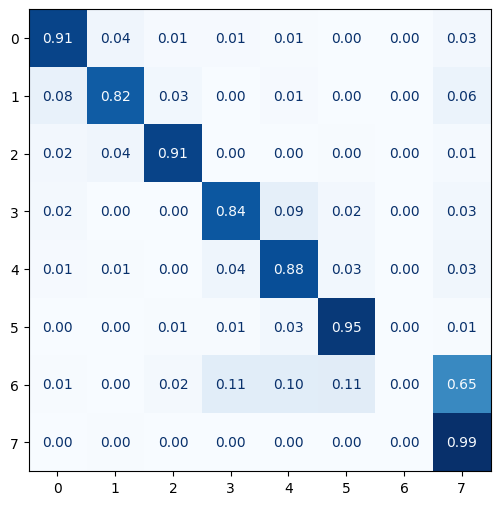

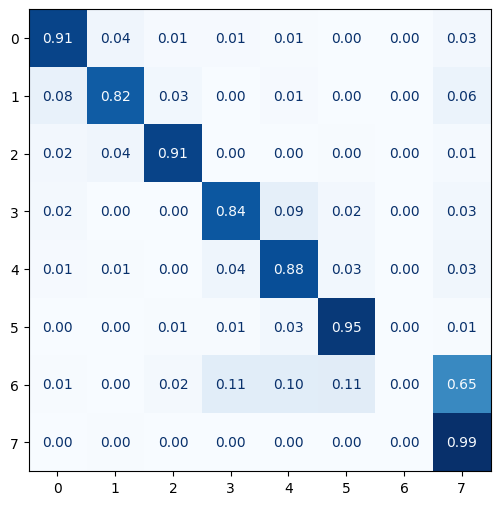

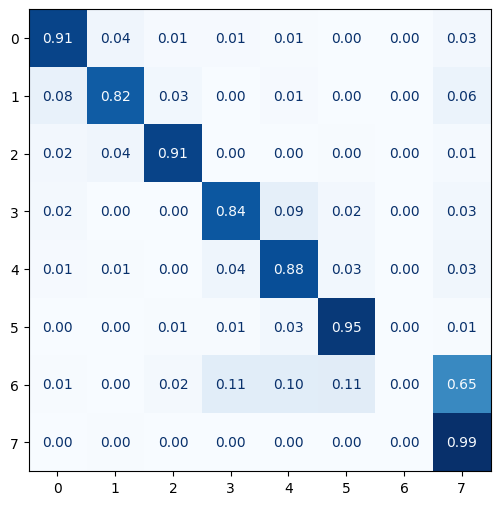

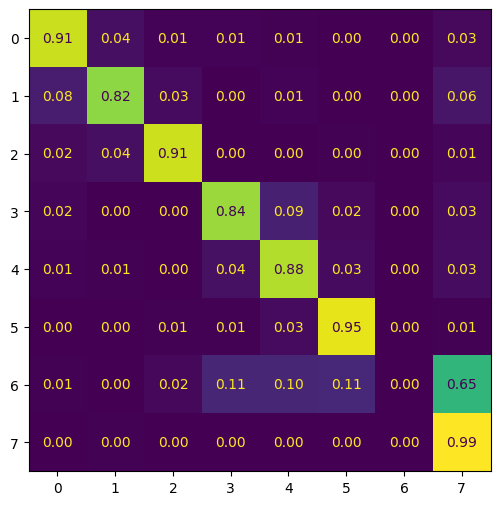

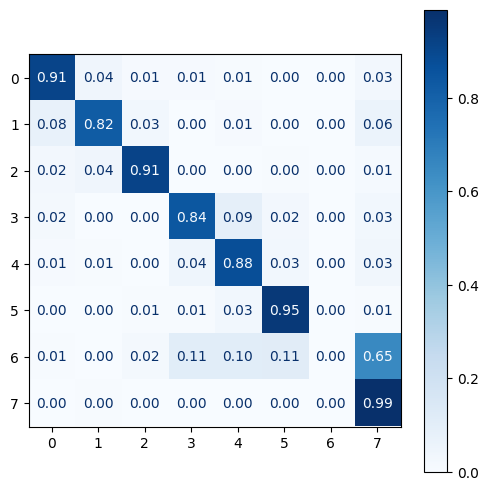

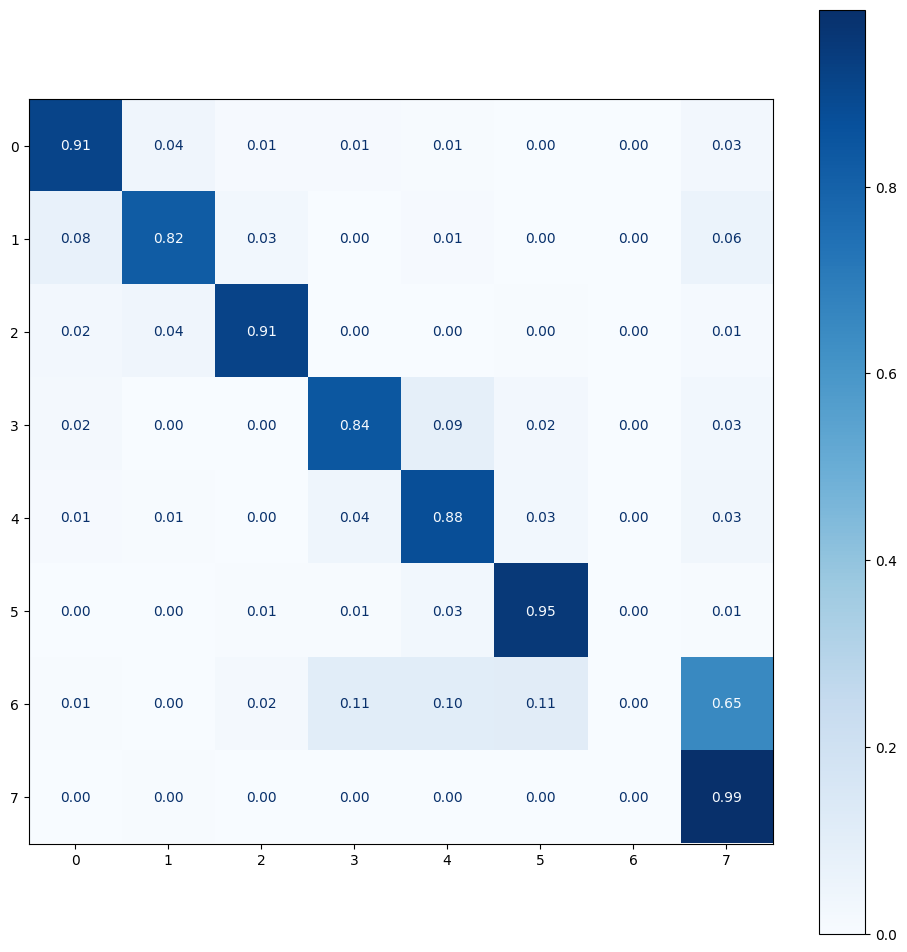

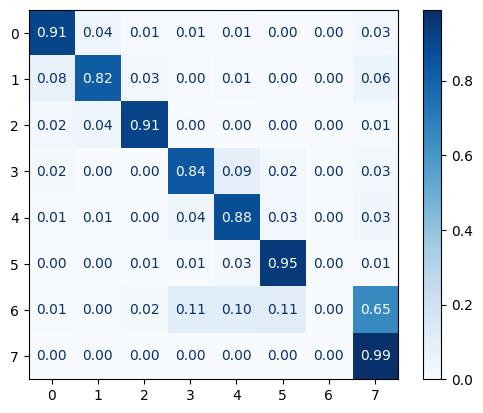

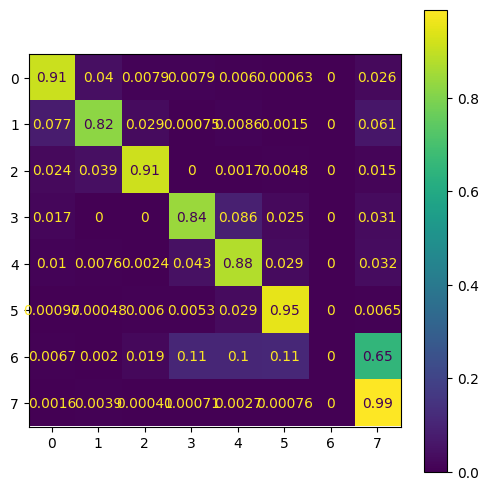

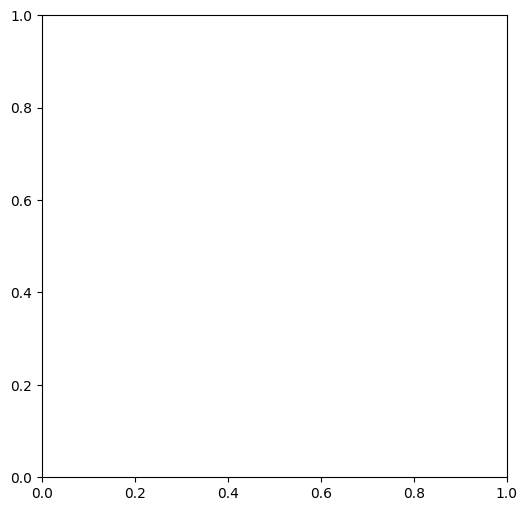

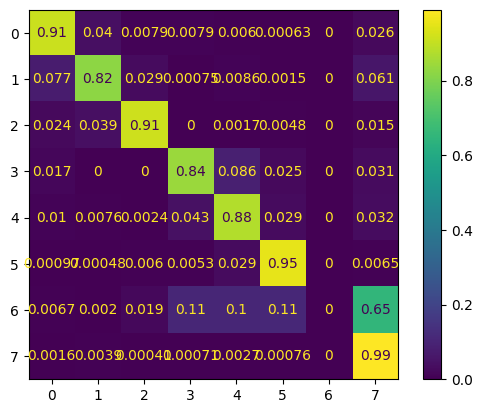

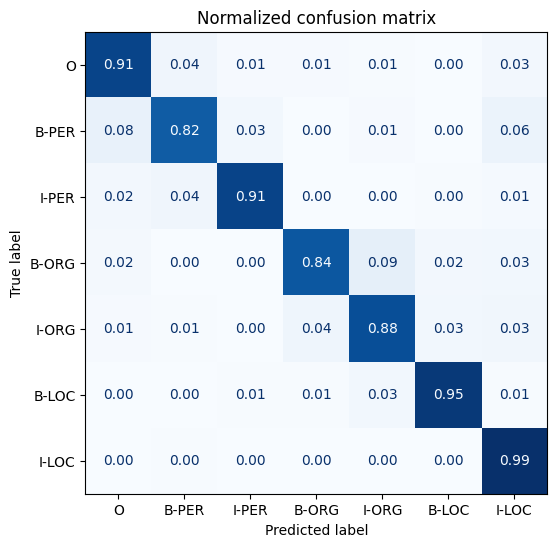

In [81]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt
%matplotlib inline

def plot_confusion_matrix(y_preds, y_true, labels):
    cm = confusion_matrix(y_true, y_preds, normalize='true')
    fig, ax = plt.subplots(figsize=(6,6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap="Blues", values_format='.2f', ax=ax, colorbar=False)
    # disp.plot()
    plt.title('Normalized confusion matrix')
    plt.show()


plot_confusion_matrix(df_tokens['predicted_label'], df_tokens['labels'], tags.names)

損失が大きい系列に並べる
+ 狙い: ラベル(正とするもの)が正しいか確認

In [85]:
def get_samples(df):
    for _, row in df.iterrows():
        labels, preds, tokens, losses = [], [], [], []
        for i, mask in enumerate(row['attention_mask']):
            if i not in {0, len(row['attention_mask'])}:
                labels.append(row['labels'][i])
                preds.append(row['predicted_label'][i])
                tokens.append(row['input_tokens'][i])
                losses.append(f"{row['loss'][i]:.2f}")
        df_tmp = pd.DataFrame({"tokens": tokens, "loss": losses, "labels": labels, "preds": preds,  }).T
        yield df_tmp

In [86]:
df['total_loss'] = df['loss'].apply(sum)
print("total_loss", df['total_loss'])
df_tmp = df.sort_values(by="total_loss", ascending=False).head(3)

for sample in get_samples(df_tmp):
    display(sample)

total_loss 0        0.052364
1        3.677949
2        0.490173
3        0.037315
4        0.009263
          ...    
6285     0.026355
6286     0.096708
6287     0.051770
6288    11.628283
6289     2.984838
Name: total_loss, Length: 6290, dtype: float32


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
tokens,▁'',8,.,▁Juli,▁'',▁:,▁Protest,camp,▁auf,▁dem,▁Gelände,▁der,▁Republika,n,ischen,▁Gar,de,</s>
loss,7.49,0.00,0.00,5.42,8.81,8.87,5.91,0.00,7.36,9.00,8.05,7.71,4.13,0.00,0.00,0.01,0.00,0.00
labels,B-ORG,IGN,IGN,I-ORG,I-ORG,I-ORG,I-ORG,IGN,I-ORG,I-ORG,I-ORG,I-ORG,I-ORG,IGN,IGN,I-ORG,IGN,IGN
preds,O,O,O,O,O,O,O,O,O,O,O,O,B-ORG,I-ORG,I-ORG,I-ORG,I-ORG,O


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
tokens,▁',▁'',▁Τ,Κ,▁'',▁',▁',▁'',▁T,▁'',▁',ri,▁'',▁',k,▁'',▁',ala,</s>
loss,0.00,0.00,3.61,0.00,0.00,0.00,9.19,9.35,5.87,6.84,6.81,0.00,7.13,7.00,0.00,7.57,6.19,0.00,0.00
labels,O,O,O,IGN,O,O,B-LOC,I-LOC,I-LOC,I-LOC,I-LOC,IGN,I-LOC,I-LOC,IGN,I-LOC,I-LOC,IGN,IGN
preds,O,O,B-ORG,I-ORG,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
tokens,▁United,▁Nations,▁Multi,dimensional,▁Integra,ted,▁Stabil,ization,▁Mission,▁in,▁the,▁Central,▁African,▁Republic,</s>
loss,5.73,5.68,5.94,0.00,5.81,0.00,5.70,0.00,5.10,4.09,5.12,5.47,5.34,5.09,0.00
labels,B-PER,I-PER,I-PER,IGN,I-PER,IGN,I-PER,IGN,I-PER,I-PER,I-PER,I-PER,I-PER,I-PER,IGN
preds,B-ORG,I-ORG,I-ORG,I-ORG,I-ORG,I-ORG,I-ORG,I-ORG,I-ORG,I-ORG,I-ORG,I-ORG,I-ORG,I-ORG,I-ORG


括弧やスラッシュの損失が比較的大きい理由を探る
+ 始まりが括弧の系列の事例をチェック

In [87]:
df.columns

Index(['input_ids', 'attention_mask', 'labels', 'loss', 'predicted_label',
       'input_tokens', 'total_loss'],
      dtype='object')

In [88]:
df_tmp = df.loc[df['input_tokens'].apply(lambda x: u"\u2581(" in x)].head(2)
for sample in get_samples(df_tmp):
    display(sample)

,0,1,2,3,4,5
tokens,▁Ham,a,▁(,▁Unternehmen,▁),</s>
loss,0.02,0.00,0.01,0.01,0.01,0.00
labels,B-ORG,IGN,I-ORG,I-ORG,I-ORG,IGN
preds,B-ORG,I-ORG,I-ORG,I-ORG,I-ORG,I-ORG


,0,1,2,3,4,5,6,7
tokens,▁Kesk,kül,a,▁(,▁Mart,na,▁),</s>
loss,0.02,0.00,0.00,0.02,0.02,0.00,0.02,0.00
labels,B-LOC,IGN,IGN,I-LOC,I-LOC,IGN,I-LOC,IGN
preds,B-LOC,I-LOC,I-LOC,I-LOC,I-LOC,I-LOC,I-LOC,I-LOC


### 言語間転移

In [91]:
def get_f1_score(trainer, dataset):
    return trainer.predict(dataset).metrics["test_f1"]


In [92]:
f1_scores = defaultdict(dict)
f1_scores["de"]["de"] = get_f1_score(trainer, panx_de_encoded["test"])
print(f"F1-scores of [de] model on [de] dataset: {f1_scores['de']['de']:.3f}")

C:\Users\InoueShinichi\.conda\envs\Book_Transformers\Lib\site-packages\torch\nn\parallel\data_parallel.py:37: UserWarning: 
    There is an imbalance between your GPUs. You may want to exclude GPU 1 which
    has less than 75% of the memory or cores of GPU 0. You can do so by setting
    the device_ids argument to DataParallel, or by setting the CUDA_VISIBLE_DEVICES
    environment variable.
  warnings.warn(
C:\Users\InoueShinichi\.conda\envs\Book_Transformers\Lib\site-packages\torch\nn\parallel\_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


F1-scores of [de] model on [de] dataset: 0.861


ドイツ語でファインチューニングしたXLM-Rモデルがフランス語でどれだけ性能がでるかチェック

In [93]:
text_fr = "Jeff Dean est informaticien chez Google en Californie"
tag_text(text_fr, tags, trainer.model, xlmr_tokenizer)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
Tokens,<s>,▁Jeff,▁De,an,▁est,▁informatic,ien,▁chez,▁Google,▁en,▁Cali,for,nie,</s>
Tags,O,B-PER,I-PER,I-PER,O,O,O,O,B-ORG,O,B-LOC,I-LOC,I-LOC,O


In [94]:
# データセットをエンコードして分類レポートを生成する関数
def evaluate_lang_performance(lang, trainer):
    panx_ds = encode_panx_dataset(panx_ch[lang])
    return get_f1_score(trainer, panx_ds["test"])

フランス語のテストデータに対してF1スコアを計算

In [95]:
f1_scores["de"]["fr"] = evaluate_lang_performance("fr", trainer)
print(f"F1-score of [de] model on [fr] dataset: {f1_scores['de']['fr']:.3f}")

Map:   0%|          | 0/4580 [00:00<?, ? examples/s]

Map:   0%|          | 0/2290 [00:00<?, ? examples/s]

Map:   0%|          | 0/2290 [00:00<?, ? examples/s]

C:\Users\InoueShinichi\.conda\envs\Book_Transformers\Lib\site-packages\torch\nn\parallel\data_parallel.py:37: UserWarning: 
    There is an imbalance between your GPUs. You may want to exclude GPU 1 which
    has less than 75% of the memory or cores of GPU 0. You can do so by setting
    the device_ids argument to DataParallel, or by setting the CUDA_VISIBLE_DEVICES
    environment variable.
  warnings.warn(
C:\Users\InoueShinichi\.conda\envs\Book_Transformers\Lib\site-packages\torch\nn\parallel\_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


F1-score of [de] model on [fr] dataset: 0.703


イタリア語のテストデータに対してF1スコアを計算

In [96]:
f1_scores["de"]["it"] = evaluate_lang_performance("it", trainer)
print(f"F1-score of [de] model on [it] dataset: {f1_scores['de']['it']:.3f}")

Map:   0%|          | 0/1680 [00:00<?, ? examples/s]

Map:   0%|          | 0/840 [00:00<?, ? examples/s]

Map:   0%|          | 0/840 [00:00<?, ? examples/s]

C:\Users\InoueShinichi\.conda\envs\Book_Transformers\Lib\site-packages\torch\nn\parallel\data_parallel.py:37: UserWarning: 
    There is an imbalance between your GPUs. You may want to exclude GPU 1 which
    has less than 75% of the memory or cores of GPU 0. You can do so by setting
    the device_ids argument to DataParallel, or by setting the CUDA_VISIBLE_DEVICES
    environment variable.
  warnings.warn(
C:\Users\InoueShinichi\.conda\envs\Book_Transformers\Lib\site-packages\torch\nn\parallel\_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


F1-score of [de] model on [it] dataset: 0.695


英語のテストデータに対してF1スコアを計算

In [97]:
f1_scores["de"]["en"] = evaluate_lang_performance("en", trainer)
print(f"F1-score of [de] model on [en] dataset: {f1_scores['de']['en']:.3f}")

Map:   0%|          | 0/1180 [00:00<?, ? examples/s]

Map:   0%|          | 0/590 [00:00<?, ? examples/s]

Map:   0%|          | 0/590 [00:00<?, ? examples/s]

C:\Users\InoueShinichi\.conda\envs\Book_Transformers\Lib\site-packages\torch\nn\parallel\data_parallel.py:37: UserWarning: 
    There is an imbalance between your GPUs. You may want to exclude GPU 1 which
    has less than 75% of the memory or cores of GPU 0. You can do so by setting
    the device_ids argument to DataParallel, or by setting the CUDA_VISIBLE_DEVICES
    environment variable.
  warnings.warn(
C:\Users\InoueShinichi\.conda\envs\Book_Transformers\Lib\site-packages\torch\nn\parallel\_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


F1-score of [de] model on [en] dataset: 0.588


ゼロショット転移が有効な場合を探る
+ フランス語コーパスについて、学習データセットを大きくしてXLM-Rをファインチューニングする
+ ドイツ語ファインチューニングのモデルと比較する

In [98]:
def train_on_subset(dataset, num_samples):
    train_ds = dataset["train"].shuffle(seed=42).select(range(num_samples))
    valid_ds = dataset["validation"]
    test_ds = dataset["test"]
    training_args.logging_steps = len(train_ds) // batch_size

    trainer = Trainer(model_init=model_init, args=training_args,
                      data_collator=data_collator, compute_metrics=compute_metrics,
                      train_dataset=train_ds, eval_dataset=valid_ds, tokenizer=xlmr_tokenizer)

    trainer.train()

    f1_score = get_f1_score(trainer, test_ds)
    return pd.DataFrame.from_dict({
        "num_samples": [len(train_ds)],
        "f1_score": [f1_score],
    })


In [99]:
# フランス語コーパスを(入力ID, アテンションマスク, ラベルID)にエンコードする
panx_fr_encoded = encode_panx_dataset(panx_ch['fr'])

Map:   0%|          | 0/4580 [00:00<?, ? examples/s]

In [100]:
# 事例数 250件で動作確認
training_args.push_to_hub = False
metrics_df = train_on_subset(panx_fr_encoded, 250)
metrics_df

C:\Users\InoueShinichi\.conda\envs\Book_Transformers\Lib\site-packages\transformers\modeling_utils.py:1435: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.

Epoch,Training Loss,Validation Loss,F1
1,No log,1.425229,0.000000
2,1.491800,1.286498,0.000665
3,1.491800,1.223498,0.028285


,num_samples,f1_score
0,250,0.034423


In [103]:
# データセットの量を増やして比較
fr_metric_list = [metrics_df]
for num_samples in [500, 1000, 2000, 4000]:
    new_metrics_df = train_on_subset(panx_fr_encoded, num_samples)
    fr_metric_list.append(new_metrics_df)
metrics_df = pd.concat(fr_metric_list, ignore_index=True)

C:\Users\InoueShinichi\.conda\envs\Book_Transformers\Lib\site-packages\transformers\modeling_utils.py:1435: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.

Epoch,Training Loss,Validation Loss,F1
1,No log,1.240260,0.031272
2,1.297800,0.960194,0.255961
3,1.297800,0.853906,0.367098


Epoch,Training Loss,Validation Loss,F1
1,No log,0.890782,0.317775
2,1.003100,0.566929,0.572594
3,1.003100,0.461833,0.698880


Epoch,Training Loss,Validation Loss,F1
1,No log,0.409413,0.740705
2,0.652500,0.357237,0.759882
3,0.652500,0.333434,0.797275


Epoch,Training Loss,Validation Loss,F1
1,No log,0.412361,0.731289
2,0.485900,0.310531,0.817100
3,0.485900,0.277182,0.831348


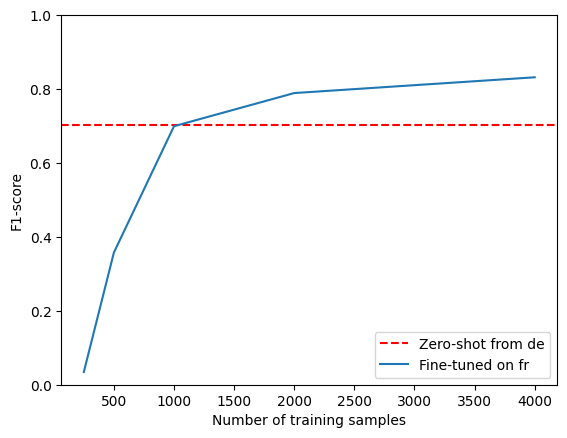

In [105]:
fig, ax = plt.subplots()
ax.axhline(f1_scores["de"]["fr"], ls="--", c="r")
metrics_df.set_index('num_samples').plot(ax=ax)
plt.legend(["Zero-shot from de", "Fine-tuned on fr"], loc="lower right")
plt.ylim(0, 1)
plt.xlabel("Number of training samples")
plt.ylabel("F1-score")
plt.show()


##### 複数言語の同時並行的なファインチューニング
+ ドイツ語とフランス語のコーパスを連結してみる

In [106]:
from datasets import concatenate_datasets

def concatenate_splits(corpora):
    multi_corpus = DatasetDict()
    for split in corpora[0].keys():
        multi_corpus[split] = concatenate_datasets([corpus[split] for corpus in corpora]).shuffle(seed=42)
    return multi_corpus

In [107]:
panx_de_fr_encoded = concatenate_splits([panx_de_encoded, panx_fr_encoded])

In [108]:
# 学習
training_args.logging_step = len(panx_de_fr_encoded['train']) // batch_size
training_args.push_to_hub = False
training_args.output_dir = "xlm-roberta-base-finetuded-panx-de-fr"

trainer = Trainer(model_init=model_init, args=training_args,
                  data_collator=data_collator, compute_metrics=compute_metrics,
                  tokenizer=xlmr_tokenizer, train_dataset=panx_de_fr_encoded['train'],
                  eval_dataset=panx_de_fr_encoded['validation'],)
trainer.train()


C:\Users\InoueShinichi\.conda\envs\Book_Transformers\Lib\site-packages\transformers\modeling_utils.py:1435: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.

Epoch,Training Loss,Validation Loss,F1
1,0.219900,0.180290,0.826693
2,0.147200,0.159898,0.845990
3,0.104600,0.155769,0.854764


TrainOutput(global_step=1074, training_loss=0.18538928964284546, metrics={'train_runtime': 1298.0876, 'train_samples_per_second': 39.658, 'train_steps_per_second': 0.827, 'total_flos': 1325495879994528.0, 'train_loss': 0.18538928964284546, 'epoch': 3.0})

In [109]:
# 各言語の評価データセットでモデルがどのような性能を示すかチェック
for lang in langs:
    f1 = evaluate_lang_performance(lang, trainer)
    print(f"F1-score of [{lang}] model on [{lang}] dataset: {f1:.3f}")

C:\Users\InoueShinichi\.conda\envs\Book_Transformers\Lib\site-packages\torch\nn\parallel\data_parallel.py:37: UserWarning: 
    There is an imbalance between your GPUs. You may want to exclude GPU 1 which
    has less than 75% of the memory or cores of GPU 0. You can do so by setting
    the device_ids argument to DataParallel, or by setting the CUDA_VISIBLE_DEVICES
    environment variable.
  warnings.warn(
C:\Users\InoueShinichi\.conda\envs\Book_Transformers\Lib\site-packages\torch\nn\parallel\_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


F1-score of [de] model on [de] dataset: 0.862
F1-score of [fr] model on [fr] dataset: 0.852
F1-score of [it] model on [it] dataset: 0.789
F1-score of [en] model on [en] dataset: 0.683


In [110]:
# フランス語、イタリア語、英語　で単位一コーパスでファインチューニングした結果のF1スコア
corpora = [panx_de_encoded]

# ドイツ語以外に対してforを回す
for lang in langs[1:]:
    training_args.output_dir = "xlm-roberta-base-finetuned-panx-{lang}".format(lang=lang)
    # 単一言語のコーパスでファインチューニング
    ds_encoded = encode_panx_dataset(panx_ch[lang])
    metrics = train_on_subset(ds_encoded, ds_encoded['train'].num_rows)
    # F1スコアを収集
    f1_scores[lang][lang] = metrics["f1_score"][0]
    # 連結するために、単一言語のコーパスをコーパスのリストに追加
    corpora.append(ds_encoded)

C:\Users\InoueShinichi\.conda\envs\Book_Transformers\Lib\site-packages\transformers\modeling_utils.py:1435: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.

Epoch,Training Loss,Validation Loss,F1
1,No log,0.319799,0.796165
2,0.472900,0.274349,0.824520
3,0.472900,0.266001,0.833194


Epoch,Training Loss,Validation Loss,F1
1,No log,0.401756,0.690391
2,0.631300,0.302034,0.775231
3,0.631300,0.267674,0.810612


Epoch,Training Loss,Validation Loss,F1
1,No log,0.764707,0.503832
2,0.932600,0.480455,0.609350
3,0.932600,0.427560,0.647027


In [111]:
# ドイツ語、フランス語、イタリア語、英語、の全４言語を連結したコーパスでのファインチューニング
corpora_encoded = concatenate_splits(corpora) # 多言語コーパス

In [112]:
# 多言語コーパスで一つのXLM-Rモデルをファインチューニング
training_args.logging_step = len(corpora_encoded['train']) // batch_size
training_args.push_to_hub = False
training_args.output_dir = "xlm-roberta-base-finetuded-panx-all"

trainer = Trainer(model_init=model_init, args=training_args,
                  data_collator=data_collator, compute_metrics=compute_metrics,
                  tokenizer=xlmr_tokenizer, train_dataset=corpora_encoded['train'],
                  eval_dataset=corpora_encoded['validation'],)
trainer.train()



C:\Users\InoueShinichi\.conda\envs\Book_Transformers\Lib\site-packages\transformers\modeling_utils.py:1435: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.

Epoch,Training Loss,Validation Loss,F1
1,0.205900,0.190268,0.818254
2,0.148000,0.164744,0.846579
3,0.103100,0.167369,0.853346


TrainOutput(global_step=1254, training_loss=0.1945096708750991, metrics={'train_runtime': 1481.4573, 'train_samples_per_second': 40.541, 'train_steps_per_second': 0.846, 'total_flos': 1517976179902248.0, 'train_loss': 0.1945096708750991, 'epoch': 3.0})

In [113]:
# 多言語実験結果のまとめ
for idx, lang in enumerate(langs):
    f1_scores['all'][lang] = get_f1_score(trainer, corpora[idx]['test']) # テストデータに対するF1スコア

scores_data = {
    "de": f1_scores["de"]["de"],
    "each": {
        lang: f1_scores[lang][lang] for lang in langs
    },
    "all": f1_scores["all"]
}

f1_scores_df = pd.DataFrame(scores_data).T.round(4)
f1_scores_df.rename_axis(index="Fine-tuned on", columns="Evaluated on", inplace=True)

f1_scores_df

C:\Users\InoueShinichi\.conda\envs\Book_Transformers\Lib\site-packages\torch\nn\parallel\data_parallel.py:37: UserWarning: 
    There is an imbalance between your GPUs. You may want to exclude GPU 1 which
    has less than 75% of the memory or cores of GPU 0. You can do so by setting
    the device_ids argument to DataParallel, or by setting the CUDA_VISIBLE_DEVICES
    environment variable.
  warnings.warn(
C:\Users\InoueShinichi\.conda\envs\Book_Transformers\Lib\site-packages\torch\nn\parallel\_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Evaluated on,de,fr,it,en
Fine-tuned on,,,,
de,0.8613,0.8613,0.8613,0.8613
each,0.8613,0.8371,0.7822,0.6632
all,0.8621,0.8618,0.8687,0.7730
